In [ ]:
from firedrake import *
import matplotlib.pyplot as plt
import numpy as np
import math

# parameters
mesh_sizes = [8, 16, 32, 64]
poly_orders = [1, 2, 3]
plot_cases = [(16, 1), (32, 2), (64, 3)]

# Exact solution and forcing
def exact_expression(x, y):
    return sin(pi * x) * cos(pi * y)    #exact function

def forcing_expression(x, y):
    return 2 * pi**2 * sin(pi * x) * cos(pi * y)      #forced function


def solve_poisson_case(nx, p):
    ny = nx
    h = 1.0 / nx

    mesh = UnitSquareMesh(nx, ny, quadrilateral=True)

    # Continuous Galerkin function space of degree p
    V = FunctionSpace(mesh, "CG", p)

    # symbolic coordinates or the mesh coordinates
    x, y = SpatialCoordinate(mesh)

    # exact solution and forcing interpolated into V
    u_exact = Function(V, name="u_exact").interpolate(exact_expression(x, y))
    f = Function(V, name="forcing").interpolate(forcing_expression(x, y))

   
    # Method 1: standard weak-form FEM

    # step 1: 
    u = TrialFunction(V)    # The unknown or variable u(x,y)
    v = TestFunction(V)     # The testfunction of u

   #step 2:
    #here we are not using fem expension   
    a = inner(grad(u), grad(v)) * dx    # first term of the weak form
    L = f * v * dx            # second term of the weak form
    
    #step 3:
    #FEM expansion using u~u_1
    u_1 = Function(V, name="u_1")
    
    #Dirichlet boundary conditions at x=0,1 are imposed using,
    bc_x0 = DirichletBC(V, Constant(0.0), 1)
    bc_x1 = DirichletBC(V, Constant(0.0), 2)
    #we are not imposing Neumann boundary conditions, as they are automatically included

    #step 4:
    #solving the algebraic system to find u_1
    solve(a == L, u_1, bcs=[bc_x0, bc_x1], solver_parameters={ "ksp_type": "cg", "pc_type": "hypre" })
   
    # Method 2: Ritz-Galerkin / energy minimisation
    
    #step 1:
    #solution u_2 that minimises the functional J[u] =Ju
    u_2 = Function(V, name="u_2")

    #step 2:
    # using the same test function v
    Ju = (0.5 * inner(grad(u_2), grad(u_2)) - u_2 * f) * dx

    #step 3:
    #derivative of the functional with respect to u_2 in the direction of v
    F = derivative(Ju, u_2, du=v)

    #step 4:
    #solving F=0 to find u_2
    solve(F == 0, u_2, bcs=[bc_x0, bc_x1], solver_parameters={"ksp_type": "cg", "pc_type": "hypre"} )

    # Error Analysis for both methods
 
    # Error functions for absolute error and difference between methods
    abs_error_1 = Function(V, name="abs_error_1")
    abs_error_1.interpolate(abs(u_1 - u_exact))

    abs_error_2 = Function(V, name="abs_error_2")
    abs_error_2.interpolate(abs(u_2 - u_exact))

    method_diff = Function(V, name="method_diff")
    method_diff.interpolate(abs(u_2 - u_1))

    # Error norms with exact solution and between methods
    
    L2_error_1 = errornorm(u_exact, u_1, norm_type="L2")
    H1_error_1 = errornorm(u_exact, u_1, norm_type="H1")

    L2_error_2 = errornorm(u_exact, u_2, norm_type="L2")
    H1_error_2 = errornorm(u_exact, u_2, norm_type="H1")

    L2_between_methods = sqrt(assemble((u_2 - u_1) * (u_2 - u_1) * dx))

    ndofs = V.dim()

    return {"nx": nx, "ny": ny, "h": h, "p": p, "ndofs": ndofs, "mesh": mesh, "V": V, "u_exact": u_exact, "u_1": u_1, "u_2": u_2,
        "abs_error_1": abs_error_1, "abs_error_2": abs_error_2, "method_diff": method_diff, "L2_error_1": L2_error_1,
        "H1_error_1": H1_error_1, "L2_error_2": L2_error_2, "H1_error_2": H1_error_2, "L2_between_methods": L2_between_methods}


def sample_on_grid(func, nx_plot=151, ny_plot=151):

    #creating a meshgrid of points in the domain
    xvals = np.linspace(0.0, 1.0, nx_plot)
    yvals = np.linspace(0.0, 1.0, ny_plot)
    X, Y = np.meshgrid(xvals, yvals)

    #matrix of values for u at each point on the grid
    U = np.zeros_like(X)
    for j in range(ny_plot):
        for i in range(nx_plot):
            U[j, i] = func.at([X[j, i], Y[j, i]])

    return X, Y, U


#countour plotting function

def make_contour_plot(X, Y, U, title, levels=20):
    plt.figure(figsize=(7, 5.5))
    contour = plt.contourf(X, Y, U, levels=levels)
    cbar = plt.colorbar(contour)
    cbar.set_label("Value")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.tight_layout()
    plt.show()    



firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance



Running for p = 1
nx = 8, p = 1, L2_1 = 6.214e-03, L2_2 = 6.214e-03, diff = 3.829e-17, rate = nan
nx = 16, p = 1, L2_1 = 1.593e-03, L2_2 = 1.593e-03, diff = 5.546e-17, rate = 1.964
Showing contour plots for h = 0.06250, p = 1


/home/neeru/data-driven/FEM/venv-firedrake/lib/python3.10/site-packages/firedrake/function.py:560: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(
/home/neeru/data-driven/FEM/venv-firedrake/lib/python3.10/site-packages/firedrake/function.py:560: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(


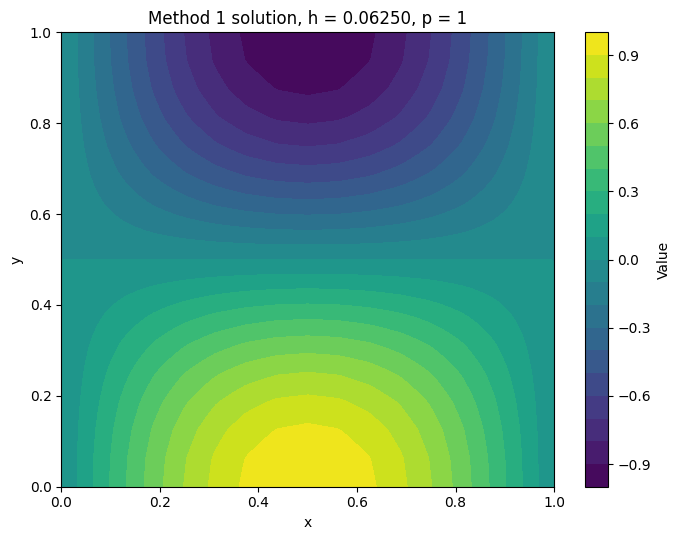

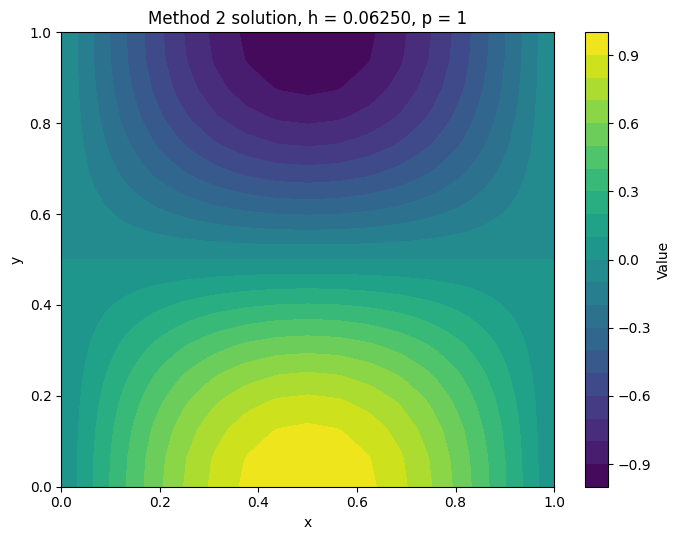

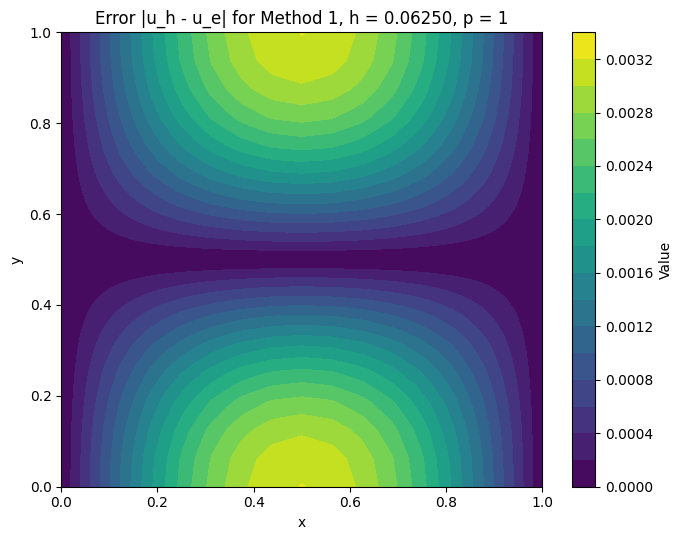

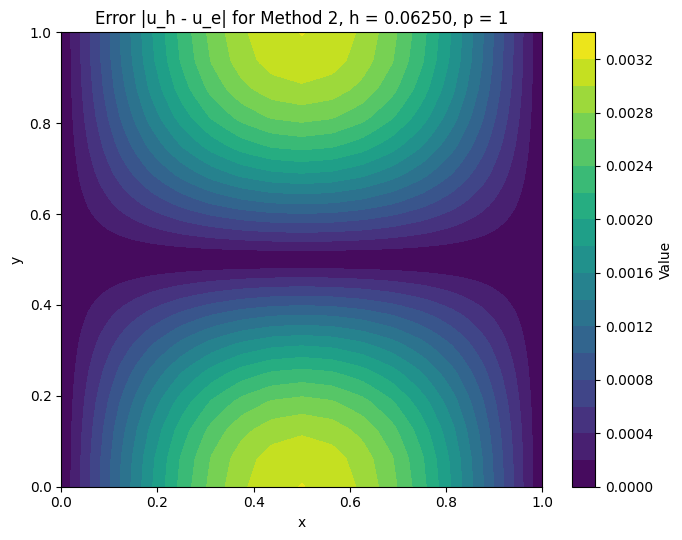

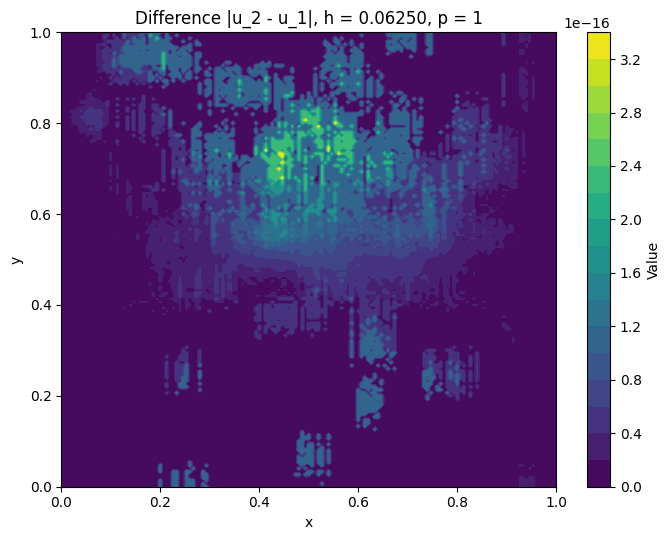

nx = 32, p = 1, L2_1 = 4.008e-04, L2_2 = 4.008e-04, diff = 3.108e-16, rate = 1.991
nx = 64, p = 1, L2_1 = 1.003e-04, L2_2 = 1.003e-04, diff = 2.792e-16, rate = 1.998

Running for p = 2
nx = 8, p = 2, L2_1 = 1.657e-05, L2_2 = 1.657e-05, diff = 5.131e-16, rate = nan
nx = 16, p = 2, L2_1 = 1.043e-06, L2_2 = 1.043e-06, diff = 5.778e-16, rate = 3.990
nx = 32, p = 2, L2_1 = 6.528e-08, L2_2 = 6.528e-08, diff = 2.468e-15, rate = 3.998
Showing contour plots for h = 0.03125, p = 2


/home/neeru/data-driven/FEM/venv-firedrake/lib/python3.10/site-packages/firedrake/function.py:560: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(
/home/neeru/data-driven/FEM/venv-firedrake/lib/python3.10/site-packages/firedrake/function.py:560: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(


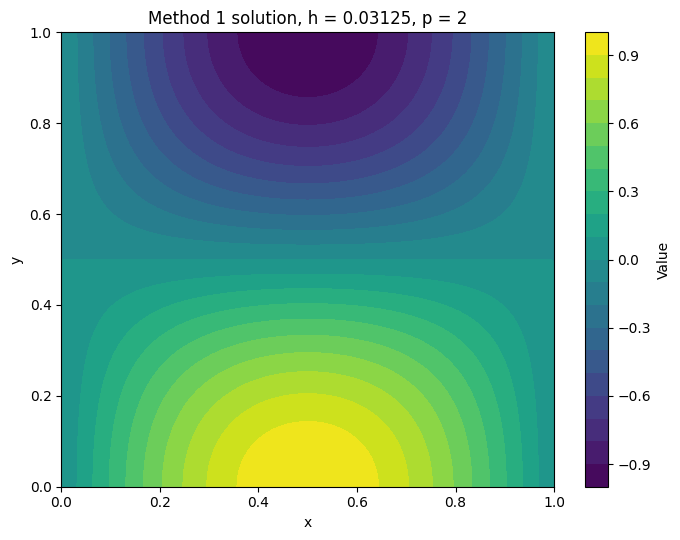

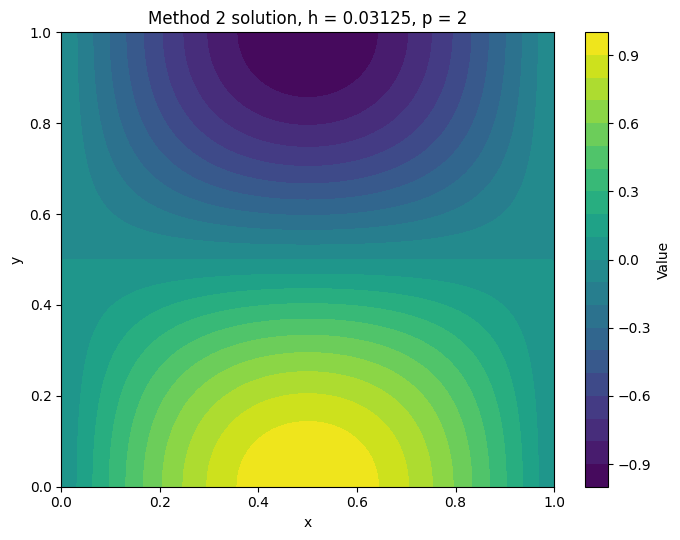

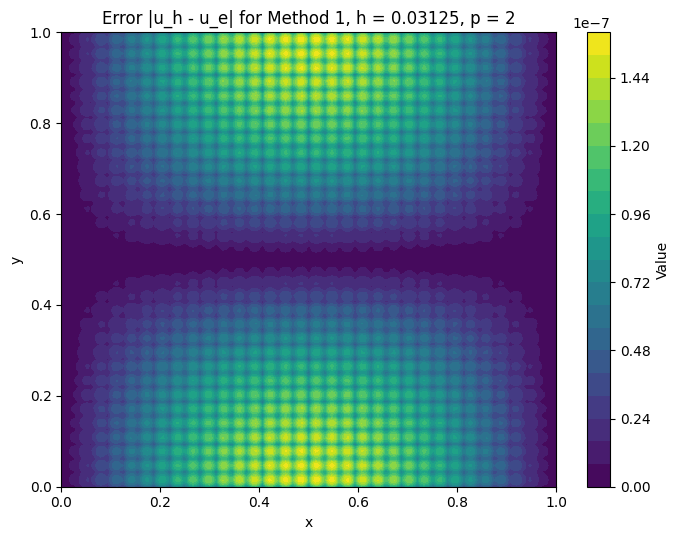

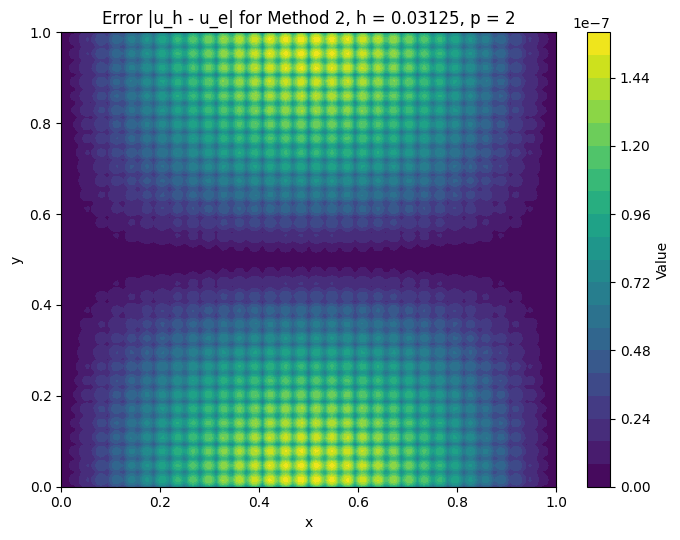

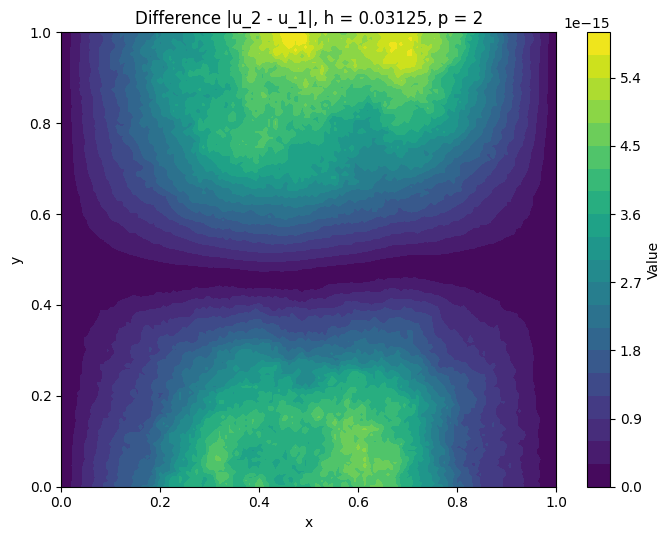

nx = 64, p = 2, L2_1 = 4.082e-09, L2_2 = 4.082e-09, diff = 3.618e-15, rate = 3.999

Running for p = 3
nx = 8, p = 3, L2_1 = 1.070e-07, L2_2 = 1.070e-07, diff = 1.883e-17, rate = nan
nx = 16, p = 3, L2_1 = 3.379e-09, L2_2 = 3.379e-09, diff = 1.921e-17, rate = 4.985
nx = 32, p = 3, L2_1 = 1.059e-10, L2_2 = 1.059e-10, diff = 1.912e-17, rate = 4.996
nx = 64, p = 3, L2_1 = 3.347e-12, L2_2 = 3.347e-12, diff = 1.901e-17, rate = 4.983
Showing contour plots for h = 0.01562, p = 3


/home/neeru/data-driven/FEM/venv-firedrake/lib/python3.10/site-packages/firedrake/function.py:560: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(
/home/neeru/data-driven/FEM/venv-firedrake/lib/python3.10/site-packages/firedrake/function.py:560: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(


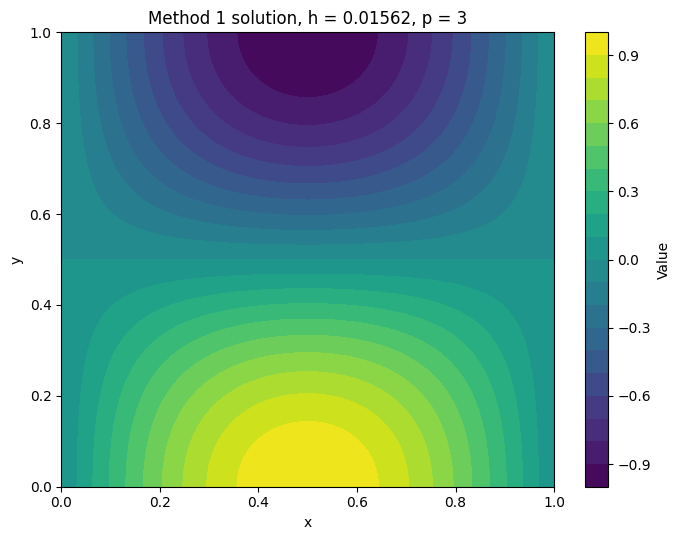

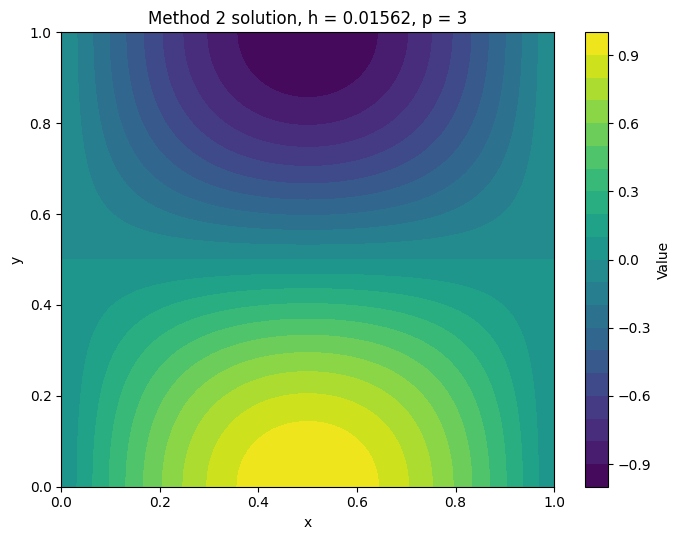

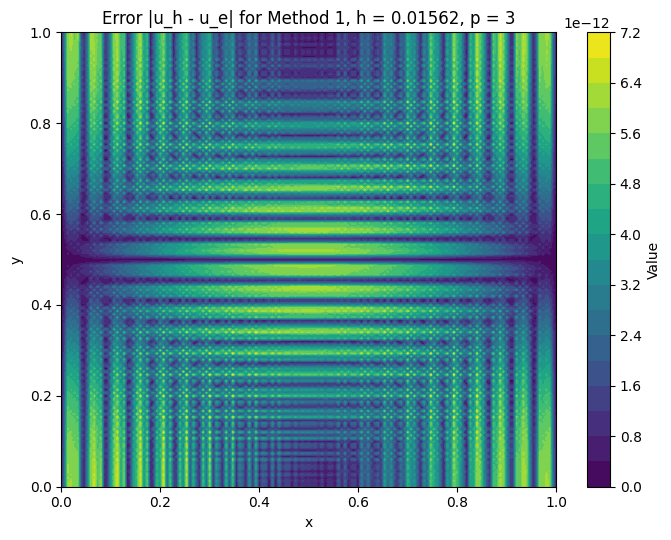

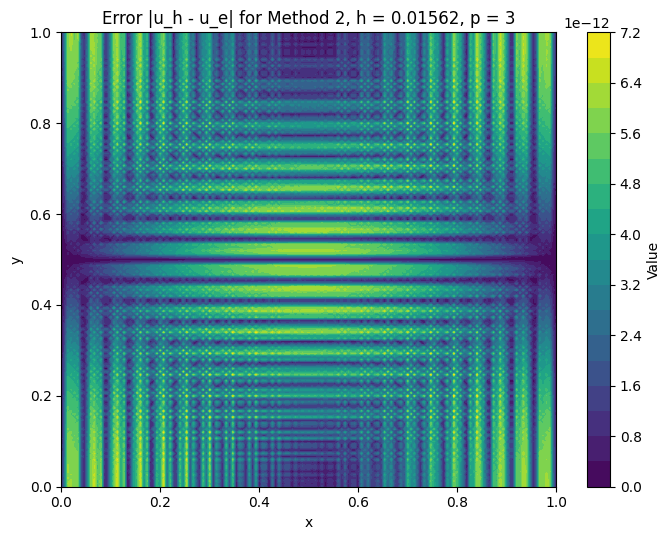

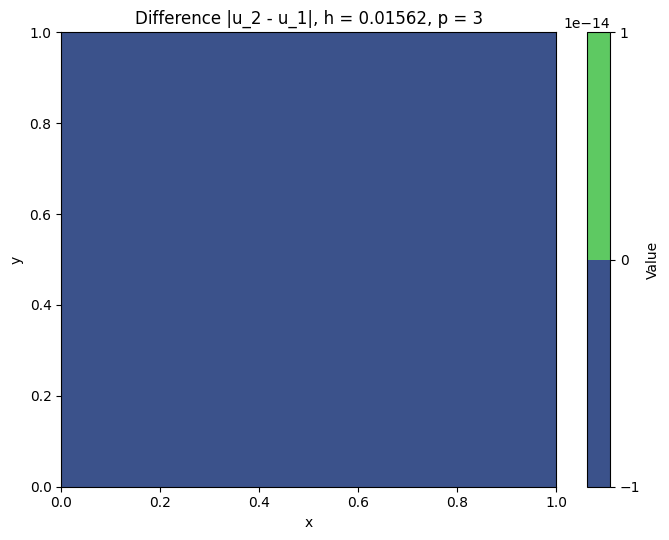

In [2]:
#excutation
results = []

for p in poly_orders:
    print(f"\nRunning for p = {p}")
    old = None

    for nx in mesh_sizes:
        data = solve_poisson_case(nx, p)
        results.append(data)

        if old is None:
            rate1 = float("nan")
            rate2 = float("nan")
        else:
            rate1 = math.log(old["L2_error_1"] / data["L2_error_1"]) / math.log(old["h"] / data["h"])
            rate2 = math.log(old["L2_error_2"] / data["L2_error_2"]) / math.log(old["h"] / data["h"])

        print(
            f"nx = {nx}, p = {p}, "
            f"L2_1 = {data['L2_error_1']:.3e}, "
            f"L2_2 = {data['L2_error_2']:.3e}, "
            f"diff = {data['L2_between_methods']:.3e}, "
            f"rate = {rate1:.3f}"
        )

        old = data

        if (nx, p) in plot_cases:
            print(f"Showing contour plots for h = {data['h']:.5f}, p = {p}")

            X, Y, U1 = sample_on_grid(data["u_1"], nx_plot=151, ny_plot=151)
            _, _, U2 = sample_on_grid(data["u_2"], nx_plot=151, ny_plot=151)
            _, _, Ue = sample_on_grid(data["u_exact"], nx_plot=151, ny_plot=151)

            Uerr1 = np.abs(U1 - Ue)
            Uerr2 = np.abs(U2 - Ue)
            Udiff = np.abs(U2 - U1)

            make_contour_plot(X, Y, U1, f"Method 1 solution, h = {data['h']:.5f}, p = {p}")
            make_contour_plot(X, Y, U2, f"Method 2 solution, h = {data['h']:.5f}, p = {p}")
            make_contour_plot(X, Y, Uerr1, f"Error |u_h - u_e| for Method 1, h = {data['h']:.5f}, p = {p}")
            make_contour_plot(X, Y, Uerr2, f"Error |u_h - u_e| for Method 2, h = {data['h']:.5f}, p = {p}")
            make_contour_plot(X, Y, Udiff, f"Difference |u_2 - u_1|, h = {data['h']:.5f}, p = {p}")

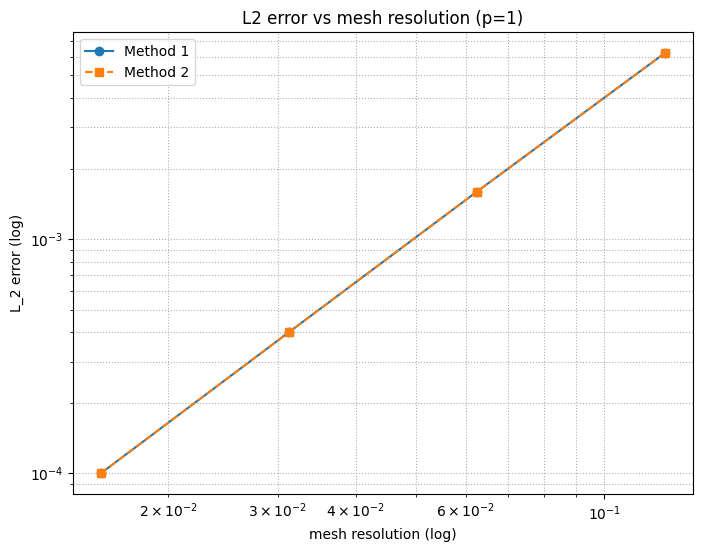

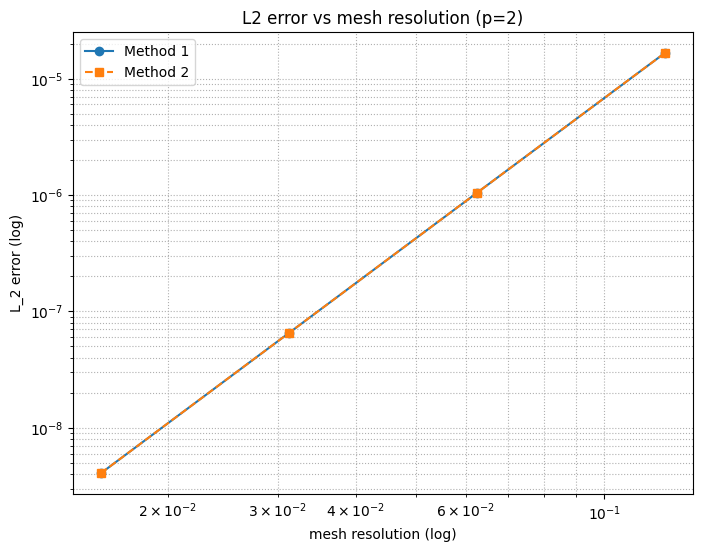

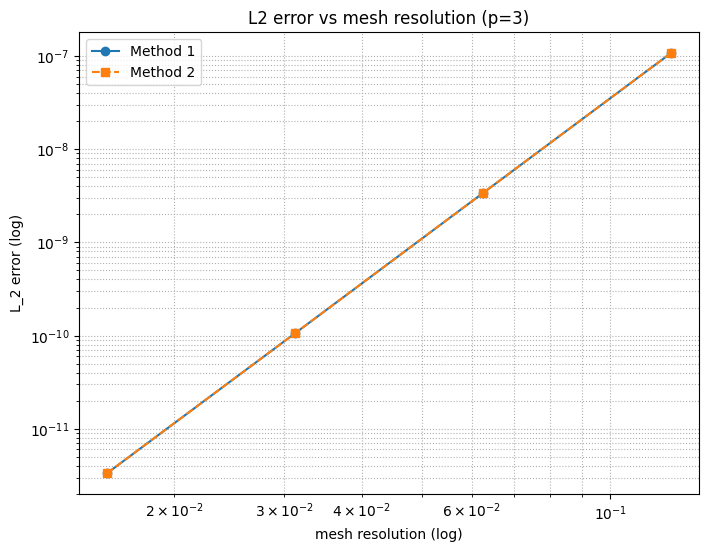

In [15]:
for p in poly_orders:
    h_vals = []
    L2_vals_1 = []
    L2_vals_2 = []

    for r in results:
        if r["p"] == p:
            h_vals.append(r["h"])
            L2_vals_1.append(r["L2_error_1"])
            L2_vals_2.append(r["L2_error_2"])

    plt.figure(figsize=(8, 6))
    plt.loglog(h_vals, L2_vals_1, marker='o',label='Method 1')
    plt.loglog(h_vals, L2_vals_2, marker='s', linestyle='--', label='Method 2')
    plt.xlabel("mesh resolution (log)")
    plt.ylabel("L_2 error (log)")
    plt.title(f"L2 error vs mesh resolution (p={p})")
    plt.legend()
    plt.grid(True, which="both", linestyle=":")
    plt.show()